<a href="https://colab.research.google.com/github/khushikayy/sklearn_library/blob/main/sklearn(11)_imbalance_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/creditcard.csv')

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
# check imbalance data
df['Class'].value_counts()

,count
Class,
0.0,59348
1.0,162


<Axes: xlabel='Class'>

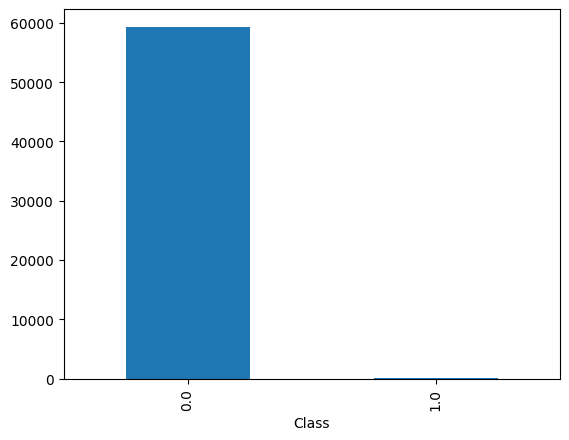

In [ ]:
df['Class'].value_counts().plot(kind='bar')

In [ ]:
df.shape

(59511, 31)

In [ ]:
df = df.sample(n=20000)

df['Class'].value_counts()

,count
Class,
0.0,19932
1.0,68


# Train model on imbalance dataset

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1 )
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Calculate accuracy
accuracy = rf_model.score(X_test, y_test)
print("Accuracy:", accuracy)

Confusion Matrix:
[[3985    2]
 [   3   10]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3987
         1.0       0.83      0.77      0.80        13

    accuracy                           1.00      4000
   macro avg       0.92      0.88      0.90      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy: 0.99875


## Apply Sampling Techniques: (RandomeOverSampler)

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Initialize RandomOverSampler
ros = RandomOverSampler()

# Perform Random Oversampling
X_ros, y_ros = ros.fit_resample(X_train, y_train)

In [ ]:
y_ros.value_counts()

,count
Class,
0.0,15945
1.0,15945


In [ ]:
# Initialize the model
rf_model_ros = RandomForestClassifier()

# Train the model on Random Oversampled data
rf_model_ros.fit(X_ros, y_ros)

# predict on the test set
y_pred_ros = rf_model_ros.predict(X_test)

# Calculate confusion matrix
conf_matrix_ros = confusion_matrix(y_test, y_pred_ros)
print("Confusion Matrix:")
print(conf_matrix_ros)

# Calculate classification report
class_report_ros = classification_report(y_test, y_pred_ros)
print("\nClassification Report:")
print(class_report_ros)

#Calculate accuracy
accuracy_ros = rf_model_ros.score(X_test, y_test)
print("Accuracy:", accuracy_ros)

Confusion Matrix:
[[3986    1]
 [   3   10]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3987
         1.0       0.91      0.77      0.83        13

    accuracy                           1.00      4000
   macro avg       0.95      0.88      0.92      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy: 0.999


## Random Undersampling: (RandomeUnderSampler)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Initialize RandomUnderSampler
rus = RandomUnderSampler()

#Perform Random Undersampling
X_rus, y_rus = rus.fit_resample(X_train, y_train)

y_rus.value_counts()

,count
Class,
0.0,55
1.0,55


In [ ]:
# Initialize the model
rf_model_rus = RandomForestClassifier()

# Train the model on Random Undersampled data
rf_model_rus.fit(X_rus, y_rus)

# Predict on the test set
y_pred_rus = rf_model_rus.predict(X_test)

# Calculate confusion matrix
conf_matrix_rus = confusion_matrix(y_test, y_pred_rus)
print("Confusion Matrix: (Random Undersampling):")
print(conf_matrix_rus)

# Calculate classification report
class_report_rus = classification_report(y_test, y_pred_rus)
print("\nClassification Report:")
print(class_report_rus)

# Calculate accuracy
accuracy_rus = rf_model_rus.score(X_test, y_test)
print("Accuracy (Random Undersampling):", accuracy_ros)


Confusion Matrix: (Random Undersampling):
[[3904   83]
 [   1   12]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      3987
         1.0       0.13      0.92      0.22        13

    accuracy                           0.98      4000
   macro avg       0.56      0.95      0.61      4000
weighted avg       1.00      0.98      0.99      4000

Accuracy (Random Undersampling): 0.999


## SMOTE:

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Initialize SMOTE
smote = SMOTE()

# Perform SMOTE
X_smote, y_smote = smote.fit_resample(X_train, y_train)

y_smote.value_counts()

,count
Class,
0.0,15945
1.0,15945


In [ ]:

# Initialize the model
rf_model_smote = RandomForestClassifier()

# Train the model on SMOTE data
rf_model_smote.fit(X_smote, y_smote)

# Predict on the test set
y_pred_smote = rf_model_smote.predict(X_test)

# Calculate confusion matrix
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix (SMOTE):")
print(conf_matrix_smote)

# Calculate classification report
class_report_smote = classification_report(y_test, y_pred_smote)
print("\nClassification Report (SMOTE):")
print(class_report_smote)

# Calculate accuracy
accuracy_smote = rf_model_smote.score(X_test, y_test)
print("Accuracy (SMOTE):", accuracy_smote)

Confusion Matrix (SMOTE):
[[3985    2]
 [   3   10]]

Classification Report (SMOTE):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3987
         1.0       0.83      0.77      0.80        13

    accuracy                           1.00      4000
   macro avg       0.92      0.88      0.90      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy (SMOTE): 0.99875


## Prediction

In [ ]:
# Get the input data as a 2D array
input_1 = X_test.iloc[[10]].values

# Predict with the model
prediction = rf_model_smote.predict(input_1)

print("Actual Class:", y_test.iloc[10])
print("Predicted Class:", prediction[0])


Actual Class: 0.0
Predicted Class: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Get the input data as a 2D array
input_2 = X_test.iloc[[101]].values

# Predict with the model
prediction = rf_model_smote.predict(input_2)

print("Actual Class:", y_test.iloc[101])
print("Predicted Class:", prediction[0])

Actual Class: 0.0
Predicted Class: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
